# 🔗 Notebook 04 — Luật kết hợp & Hệ thống Gợi ý Sản phẩm

**Mục tiêu:**
- **Luật kết hợp (Association Rules):** FP-Growth tìm cặp từ thường xuất hiện trong bình luận tiêu cực
- **Hệ thống Gợi ý:** Content-based filtering dựa trên TF-IDF Cosine Similarity
- Lưu rules và recommender để dùng trong API

**Đầu vào:** `datas/processed/reviews_with_clusters.csv`, `datas/recommend_dataset/`  
**Đầu ra:** `datas/models/association_rules.pkl`, `datas/models/recommender.pkl`

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings
import sys
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns

# Luật kết hợp
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings('ignore')
tqdm.pandas()

ROOT_DIR = Path('..').resolve()
PROCESSED_DIR = ROOT_DIR / 'datas' / 'processed'
MODELS_DIR = ROOT_DIR / 'datas' / 'models'
REC_DIR = ROOT_DIR / 'datas' / 'recommend_dataset'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT_DIR))
from src.data.catalog_builder import build_merged_catalog, load_prs_orders
from src.models.recommender import ProductRecommender
from src.models.collab_filter import CollaborativeFilteringRecommender

print('✅ Thư viện đã import thành công')

✅ Thư viện đã import thành công


## 2. Tải dữ liệu

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'reviews_with_clusters.csv')
print(f'✅ Đã tải: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
display(df.head(3))

✅ Đã tải: (31469, 6)
Columns: ['review_text', 'processed_text', 'label', 'source', 'cluster', 'cluster_name']


,review_text,processed_text,label,source,cluster,cluster_name
0,Tốt Gói Hàng đẹp Shop phục vụ rất tốt.,gói hàng đẹp shop phục_vụ,1,tiki_sentiment,5,NaN
1,Mk nhận đk hàng rồi đẹp lắm cảm ơn shop nhé 😊.,đk hàng đẹp cảm_ơn shop,1,tiki_sentiment,7,NaN
2,Bố t thích áo này lắm y.,bố áo,1,tiki_sentiment,2,Đóng gói


## 3. Luật kết hợp — FP-Growth trên Bình luận Tiêu cực

In [3]:
# Lọc bình luận tiêu cực
df_negative = df[df['label'] == 0].copy()
print(f'Số bình luận tiêu cực: {len(df_negative):,}')

Số bình luận tiêu cực: 12,116


In [4]:
def text_to_transaction(text: str, min_word_len: int = 2) -> list:
    """Chuyển văn bản thành danh sách từ (transaction) cho FP-Growth."""
    if not isinstance(text, str):
        return []
    # Tách từ và loại trùng lặp (mỗi từ chỉ xuất hiện 1 lần trong 1 transaction)
    words = text.split()
    unique_words = list(dict.fromkeys(
        w for w in words if len(w) >= min_word_len
    ))
    return unique_words

# Xây dựng tập transactions
transactions = df_negative['processed_text'].apply(text_to_transaction).tolist()
transactions = [t for t in transactions if len(t) >= 2]  # Loại transaction rỗng

print(f'Số transactions hợp lệ: {len(transactions):,}')
print(f'Ví dụ transaction: {transactions[0]}')

Số transactions hợp lệ: 5,894
Ví dụ transaction: ['dây', 'nịt', 'ngực', 'suốt', 'rách']


In [5]:
# Mã hóa transactions thành one-hot matrix
print('🔄 Đang mã hóa transactions...')
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)
print(f'✅ Transaction matrix: {df_te.shape}')

🔄 Đang mã hóa transactions...
✅ Transaction matrix: (5894, 4950)


In [6]:
# Áp dụng FP-Growth (nhanh hơn Apriori ~10x)
print('🔄 Đang chạy FP-Growth...')
MIN_SUPPORT = 0.01  # Tối thiểu 1% transactions

frequent_itemsets = fpgrowth(
    df_te,
    min_support=MIN_SUPPORT,
    use_colnames=True
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'✅ Frequent itemsets: {len(frequent_itemsets):,}')
display(frequent_itemsets.sort_values('support', ascending=False).head(10))

🔄 Đang chạy FP-Growth...
✅ Frequent itemsets: 153


,support,itemsets,length
2,0.150492,frozenset({hàng}),1
4,0.147099,frozenset({áo}),1
3,0.143196,frozenset({giao}),1
10,0.140143,frozenset({shop}),1
16,0.129793,frozenset({sản_phẩm}),1
13,0.101629,frozenset({màu}),1
31,0.097387,frozenset({vải}),1
17,0.088225,frozenset({chất_lượng}),1
40,0.082457,frozenset({mua}),1
24,0.079403,frozenset({kém}),1


In [7]:
# Tạo luật kết hợp
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.2
)

# Lọc thêm theo confidence
rules = rules[rules['confidence'] >= 0.5].copy()
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

# Chuyển frozenset thành string để dễ xử lý
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'✅ Số luật kết hợp: {len(rules):,}')
print('\nTop 15 luật theo Lift:')
display(rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].head(15))

✅ Số luật kết hợp: 59

Top 15 luật theo Lift:


,antecedents_str,consequents_str,support,confidence,lift
0,"kém, shop",phục_vụ,0.013743,0.757009,31.870093
1,phục_vụ,"kém, shop",0.013743,0.578571,31.870093
2,đường,may,0.015439,0.614865,20.474653
3,may,đường,0.015439,0.514124,20.474653
4,"chất_lượng, tiền","kém, sản_phẩm",0.011367,0.736264,13.820186
5,thời_gian,"giao, hàng",0.018154,0.891667,12.603078
6,"sản_phẩm, tiền","chất_lượng, kém",0.011367,0.683673,12.475453
7,chậm,"giao, hàng",0.013912,0.811881,11.475366
8,"chất_lượng, sản_phẩm, tiền",kém,0.011367,0.858974,10.817938
9,"kém, tiền","chất_lượng, sản_phẩm",0.011367,0.697917,10.768379


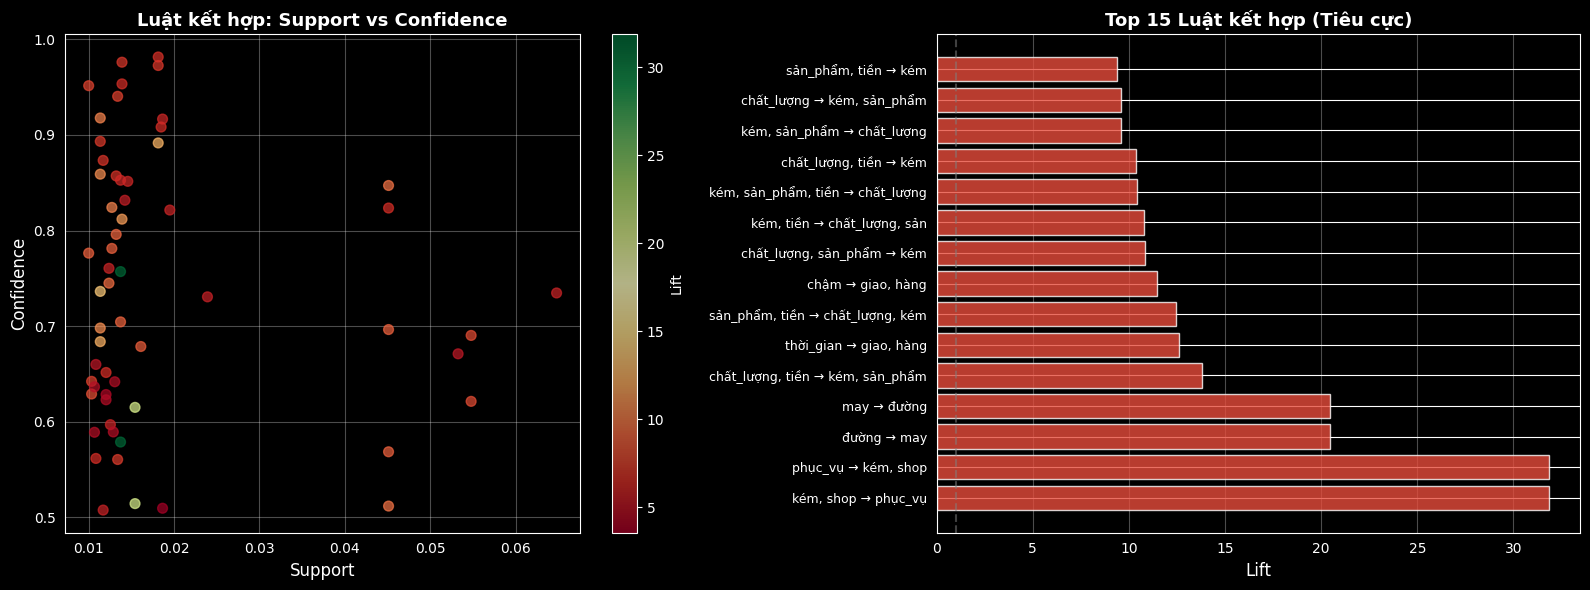

In [8]:
# Visualize top 20 luật — Heatmap Support × Confidence
top_rules = rules.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Support vs Confidence, màu = Lift
sc = axes[0].scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='RdYlGn', alpha=0.7, s=50
)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support', fontsize=12)
axes[0].set_ylabel('Confidence', fontsize=12)
axes[0].set_title('Luật kết hợp: Support vs Confidence', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Bar chart top 15 theo lift
rule_labels = [f"{a} → {c}" for a, c in zip(
    top_rules['antecedents_str'].str[:20],
    top_rules['consequents_str'].str[:15]
)][:15]
axes[1].barh(range(len(rule_labels[:15])), top_rules['lift'][:15],
             color='#e74c3c', alpha=0.8)
axes[1].set_yticks(range(len(rule_labels[:15])))
axes[1].set_yticklabels(rule_labels[:15], fontsize=9)
axes[1].set_xlabel('Lift', fontsize=12)
axes[1].set_title('Top 15 Luật kết hợp (Tiêu cực)', fontsize=13, fontweight='bold')
axes[1].axvline(x=1, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'association_rules_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Hệ thống Gợi ý Sản phẩm (Content-based)

In [9]:
# Duong dan catalog hien tai va dataset mau
CATALOG_PATH = MODELS_DIR / 'product_catalog.csv'
PRS_PRODUCTS_DIR = ROOT_DIR / 'samples' / 'product-recommendation-system' / 'datasets' / 'products_dataset'

print(f'Catalog path: {CATALOG_PATH}')
print(f'PRS products dir: {PRS_PRODUCTS_DIR} (exists={PRS_PRODUCTS_DIR.exists()})')

Catalog path: F:\codingSpace\Asm\ecom_rcm_1\datas\models\product_catalog.csv
PRS products dir: F:\codingSpace\Asm\ecom_rcm_1\samples\product-recommendation-system\datasets\products_dataset (exists=True)


In [10]:
# Hop nhat catalog hien tai + dataset mau (repo product-recommendation-system)
df_catalog = build_merged_catalog(
    existing_catalog_path=CATALOG_PATH if CATALOG_PATH.exists() else None,
    prs_products_dir=PRS_PRODUCTS_DIR if PRS_PRODUCTS_DIR.exists() else None,
    id_prefix='prs_',
    dedupe_subset=['name', 'category', 'price'],
)

print(f'✅ Product catalog: {df_catalog.shape}')
display(df_catalog[['product_id', 'name', 'category', 'price']].head(5))

✅ Product catalog: (18424, 11)


,product_id,name,category,price
0,0,[Mã ELBAU1TR giảm 5% ] Điện Thoại Samsung Gala...,Khác,0.0
1,1,"Điện Thoại Nokia 101,Nokia 100, Nokia 105 Zin ...",Khác,0.0
2,2,Điện thoại TECNO POVA2 (4GB+64GB) - Hàng chính...,Khác,0.0
3,3,Điện Thoại Siêu Dễ Thương Mini BM10 Thay Đổi G...,Khác,0.0
4,4,[Mã ELBAU1TR giảm 5% ] Điện thoại Samsung Gala...,Khác,0.0


In [11]:
# Dam bao combined_text day du cho vectorization
if 'combined_text' not in df_catalog.columns:
    df_catalog['combined_text'] = (
        df_catalog['name'].fillna('') + ' ' +
        df_catalog['category'].fillna('') + ' ' +
        df_catalog['description'].fillna('')
    ).str.strip()

missing_text = (df_catalog['combined_text'].str.len() == 0).sum()
print(f'✅ Missing combined_text: {missing_text}')
display(df_catalog.head(3))

✅ Missing combined_text: 0


,product_id,name,category,price,description,rating,image,solds,location,source,combined_text
0,0,[Mã ELBAU1TR giảm 5% ] Điện Thoại Samsung Gala...,Khác,0.0,NaN,0.0,NaN,NaN,NaN,legacy,[Mã ELBAU1TR giảm 5% ] Điện Thoại Samsung Gala...
1,1,"Điện Thoại Nokia 101,Nokia 100, Nokia 105 Zin ...",Khác,0.0,NaN,0.0,NaN,NaN,NaN,legacy,"Điện Thoại Nokia 101,Nokia 100, Nokia 105 Zin ..."
2,2,Điện thoại TECNO POVA2 (4GB+64GB) - Hàng chính...,Khác,0.0,NaN,0.0,NaN,NaN,NaN,legacy,Điện thoại TECNO POVA2 (4GB+64GB) - Hàng chính...


In [12]:
# Huấn luyện Recommender
recommender = ProductRecommender(ngram_range=(1, 2), max_features=30_000)
recommender.fit(df_catalog, text_column='combined_text')

print(f'✅ Recommender đã huấn luyện xong!')
print(f'   TF-IDF matrix: {recommender.tfidf_matrix.shape}')
print(f'   Số sản phẩm: {len(df_catalog):,}')

✅ Recommender đã huấn luyện xong!
   TF-IDF matrix: (18424, 30000)
   Số sản phẩm: 18,424


In [13]:
# Demo gợi ý
demo_queries = [
    'áo thun cotton thoáng mát',
    'điện thoại pin trâu camera đẹp',
    'kem dưỡng ẩm da mặt',
]

for query in demo_queries:
    print(f'\n🔍 Query: "{query}"')
    recs = recommender.recommend_by_query(query, top_k=5)
    if len(recs) > 0:
        display(recs)
    else:
        print('  Không tìm thấy sản phẩm phù hợp')


🔍 Query: "áo thun cotton thoáng mát"


,product_id,name,category,price,rating,similarity_score,location
16176,prs_15477,Áo Phông The Bad God Baseman - Áo Thun Chất Li...,áo thun,79.0,NaN,0.4674,NaN
14513,prs_13536,Áo Thun Acmedevi Form Rộng Thời Trang Nam Nữ C...,áo phông nữ,79.0,4.8,0.3920,Hà Nội
14347,prs_13314,ÁO THUN DAINTY Unisex Áo phông nam nữ tay lỡ o...,áo phông nam,99.0,4.8,0.3890,Bắc Ninh
13580,prs_12449,"Áo thun ba lỗ nam, tanktop 006Tk.IN, chuẩn gym...",áo ba lỗ,12.5,NaN,0.3742,NaN
13586,prs_12455,Áo thun ba lỗ nam tanktop 98 chuẩn gym mặc nhà...,áo ba lỗ,15.0,NaN,0.3487,NaN



🔍 Query: "điện thoại pin trâu camera đẹp"


,product_id,name,category,price,rating,similarity_score,location
935,968,Điện Thoại Pin Khủng Land Rover A8+,Khác,0.0,0.0,0.3513,NaN
1224,1265,Điện thoại Nokia 1280 chính hãng – CHUẦN - PIN...,Khác,0.0,0.0,0.3278,NaN
16201,prs_15502,điện thoại Vivo Y50 (8GB-128GB) -Pin trâu 5000...,điện thoại,1219000.0,NaN,0.3197,NaN
1640,1694,"Điện thoại Xiaomi Redmi 6 Pro, 2 sim pin trâu",Khác,0.0,0.0,0.3168,NaN
16179,prs_15480,Điện Thoại Thông Minh CHính Hãng Oppo A3s đã q...,điện thoại,520000.0,NaN,0.2957,NaN



🔍 Query: "kem dưỡng ẩm da mặt"


,product_id,name,category,price,rating,similarity_score,location
10353,prs_8819,Hộp Chống Ẩm Cho Máy Ảnh 10L + Hạt Hút Ẩm + Ẩm...,máy ảnh,62000.0,NaN,0.2054,NaN
17789,prs_17325,"Trà Dưỡng Sinh Túi Lọc 9 Vị, Bách Thông Dưỡng ...",đường,191425.0,NaN,0.1807,NaN
6596,prs_4438,𝐆𝐢𝐚̀𝐲 𝐓𝐡𝐞̂̉ 𝐓𝐡𝐚𝐨_𝐀𝐝𝐢𝐝𝐚𝐬 𝐒𝐚𝐦𝐛𝐚 Xám Kem ‘𝐋𝐢𝐧𝐞𝐧 𝐒...,giày nam,179000.0,NaN,0.1741,NaN
10416,prs_8882,"Hộp Chống Ẩm Cho Máy Ảnh, Ống Kính Nhỏ Gọn Tiệ...",máy ảnh,45000.0,NaN,0.1681,NaN
9059,prs_7343,Muối hầm thực dưỡng Sahu Sa Huỳnh Quảng Ngãi (...,muối,69.0,NaN,0.1539,NaN


In [14]:
# --- Collaborative Filtering (User-User) ---
ORDERS_PATH = ROOT_DIR / 'samples' / 'product-recommendation-system' / 'datasets' / 'orders_dataset' / 'order_data.csv'

if ORDERS_PATH.exists():
    df_orders = load_prs_orders(ORDERS_PATH, id_prefix='prs_')
    print(f'✅ Orders: {df_orders.shape}')
    print(f'Columns: {df_orders.columns.tolist()}')

    cf_recommender = CollaborativeFilteringRecommender(min_rating=0.0)
    cf_recommender.fit(
        df_orders, user_col='user_id', item_col='product_id', rating_col='rating'
    )

    print('✅ CF model đã huấn luyện xong!')
    print(f'   User-Item matrix: {cf_recommender.user_item_matrix.shape}')

    demo_user = df_orders['user_id'].iloc[0]
    demo_ids = cf_recommender.recommend_for_user(demo_user, top_k=5)
    print(f'🔎 Demo user: {demo_user} -> {demo_ids}')

    if demo_ids and not df_catalog.empty:
        display(df_catalog[df_catalog['product_id'].isin(demo_ids)].head(5))
else:
    print('⚠️ Không tìm thấy order_data.csv để train Collaborative Filtering')

✅ Orders: (500, 8)
Columns: ['order_id', 'user_id', 'product_id', 'product_name', 'price', 'rating', 'order_date', 'image']
✅ CF model đã huấn luyện xong!
   User-Item matrix: (99, 484)
🔎 Demo user: prs_18 -> []


In [15]:
# Tích hợp Dữ liệu Cảm xúc và Phân cụm vào Hệ thống Gợi ý (Hybrid Scoring)
import numpy as np

def get_sentiment_multiplier(product_id, df_reviews, target_cluster=None):
    """
    Tính hệ số điều chỉnh điểm gợi ý dựa trên cảm xúc và cụm chủ đề.
    Yêu cầu: df_reviews cần được map với product_id từ cơ sở dữ liệu.
    """
    # Xử lý ngoại lệ nếu tập dữ liệu hiện tại chưa map product_id (giữ nguyên hệ số 1.0)
    if 'product_id' not in df_reviews.columns:
        return 1.0

    # Lọc các bình luận thuộc về sản phẩm đang xét
    prod_reviews = df_reviews[df_reviews['product_id'] == product_id]
    if prod_reviews.empty:
        return 1.0

    # Lọc tiếp theo chủ đề người dùng quan tâm (nếu có)
    if target_cluster is not None:
        cluster_reviews = prod_reviews[prod_reviews['cluster_name'] == target_cluster]
        if not cluster_reviews.empty:
            prod_reviews = cluster_reviews

    # Tính tỷ lệ đánh giá tích cực (label = 1)
    positive_ratio = prod_reviews['label'].mean()

    # Chuyển đổi tỷ lệ tích cực thành trọng số điều chỉnh (dao động từ 0.8 đến 1.2)
    # Ví dụ: 100% tích cực -> x1.2 điểm (Thưởng) | 0% tích cực -> x0.8 điểm (Phạt)
    multiplier = 0.8 + (positive_ratio * 0.4)

    return round(multiplier, 4)

# ==========================================
# THỰC THI KIỂM THỬ KỊCH BẢN GỢI Ý LAI
# ==========================================
query = "áo thun cotton thoáng mát"
print(f'\\n🔍 Query: "{query}"')

# Lấy tập kết quả rộng hơn từ Content-Based để có không gian Re-ranking (Top 10)
recs_df = recommender.recommend_by_query(query, top_k=10)

if not recs_df.empty:
    # Áp dụng trọng số cảm xúc (Giả định ưu tiên phân tích nhóm chủ đề "Chất lượng sản phẩm")
    recs_df['sentiment_weight'] = recs_df['product_id'].apply(
        lambda x: get_sentiment_multiplier(x, df, target_cluster='Chất lượng sản phẩm')
    )

    # Hiệu chỉnh điểm số cuối cùng: final_score = TF-IDF Score * Sentiment Multiplier
    recs_df['final_score'] = recs_df['similarity_score'] * recs_df['sentiment_weight']

    # Sắp xếp lại danh sách (Re-ranking) và lấy Top 5 tốt nhất
    final_recs = recs_df.sort_values('final_score', ascending=False).head(5).reset_index(drop=True)

    print("✅ Kết quả gợi ý sau khi tích hợp Cảm xúc & Chủ đề (Re-ranking):")
    display(final_recs[['product_id', 'name', 'similarity_score', 'sentiment_weight', 'final_score']])
else:
    print('  Không tìm thấy sản phẩm phù hợp')

\n🔍 Query: "áo thun cotton thoáng mát"
✅ Kết quả gợi ý sau khi tích hợp Cảm xúc & Chủ đề (Re-ranking):


,product_id,name,similarity_score,sentiment_weight,final_score
0,prs_15477,Áo Phông The Bad God Baseman - Áo Thun Chất Li...,0.4674,1.0,0.4674
1,prs_13536,Áo Thun Acmedevi Form Rộng Thời Trang Nam Nữ C...,0.3920,1.0,0.3920
2,prs_13314,ÁO THUN DAINTY Unisex Áo phông nam nữ tay lỡ o...,0.3890,1.0,0.3890
3,prs_12449,"Áo thun ba lỗ nam, tanktop 006Tk.IN, chuẩn gym...",0.3742,1.0,0.3742
4,prs_12455,Áo thun ba lỗ nam tanktop 98 chuẩn gym mặc nhà...,0.3487,1.0,0.3487


## 5. Lưu kết quả

In [16]:
# Lưu association rules
rules_export = rules[['antecedents_str', 'consequents_str',
                       'support', 'confidence', 'lift']].copy()
rules_export.to_csv(MODELS_DIR / 'association_rules.csv',
                    index=False, encoding='utf-8-sig')
joblib.dump(rules_export, MODELS_DIR / 'association_rules.pkl')

# Lưu Recommender
joblib.dump(recommender, MODELS_DIR / 'recommender.pkl')

# Lưu catalog chuẩn hóa
df_catalog.to_csv(MODELS_DIR / 'product_catalog.csv',
                  index=False, encoding='utf-8-sig')

# Lưu Collaborative Filtering model (neu co)
if 'cf_recommender' in globals():
    joblib.dump(cf_recommender, MODELS_DIR / 'cf_recommender.pkl')

print('✅ Phase 4 hoàn thành! Các file đã lưu:')
print('  - datas/models/association_rules.pkl / .csv')
print('  - datas/models/recommender.pkl')
print('  - datas/models/product_catalog.csv')
print('  - datas/models/cf_recommender.pkl')

✅ Phase 4 hoàn thành! Các file đã lưu:
  - datas/models/association_rules.pkl / .csv
  - datas/models/recommender.pkl
  - datas/models/product_catalog.csv
  - datas/models/cf_recommender.pkl


In [17]:
# ==========================================
# HỆ THỐNG GỢI Ý LAI (HYBRID RECOMMENDER SYSTEM)
# Kết hợp Collaborative Filtering, Content-Based và Sentiment Re-ranking
# ==========================================
import pandas as pd

def hybrid_recommend(user_id, query=None, top_k=5):
    """
    Hàm đóng gói Hệ thống Gợi ý Lai.
    - user_id: Mã người dùng (VD: 'prs_18')
    - query: Câu truy vấn tìm kiếm (nếu có)
    - top_k: Số lượng sản phẩm trả về
    """
    candidates = pd.DataFrame()
    
    # 1. ĐỊNH TUYẾN (ROUTING): Ưu tiên CF nếu người dùng cũ và không nhập query
    # Lấy tập ứng viên gấp đôi (top_k * 2) để có dữ liệu cho bước Re-ranking
    if 'cf_recommender' in globals() and not query:
        try:
            cf_ids = cf_recommender.recommend_for_user(user_id, top_k=top_k * 2)
            if cf_ids:
                print(f"🔄 Routing: Kích hoạt Lọc cộng tác (CF) cho user '{user_id}'...")
                candidates = df_catalog[df_catalog['product_id'].isin(cf_ids)].copy()
                candidates['base_score'] = 1.0
        except Exception:
            # Văng lỗi do user_id không có trong ma trận CF. Bỏ qua.
            pass
            
    # 2. XỬ LÝ COLD-START HOẶC TÌM KIẾM: Kích hoạt CBF
    if candidates.empty or query is not None:
        search_query = query if query else "sản phẩm nổi bật"
        print(f"🔄 Routing: Kích hoạt Lọc nội dung (CBF) với truy vấn '{search_query}'...")
        candidates = recommender.recommend_by_query(search_query, top_k=top_k * 2)
        if not candidates.empty:
            # Đổi tên cột similarity_score thành base_score để đồng nhất luồng
            candidates.rename(columns={'similarity_score': 'base_score'}, inplace=True)
            
    # 3. TIÊM TRÍ TUỆ CẢM XÚC & XẾP HẠNG LẠI (Sentiment Re-ranking)
    if not candidates.empty:
        print("⭐ Đang áp dụng Sentiment Re-ranking...")
        # Sử dụng hàm get_sentiment_multiplier từ cell trước. 
        # Biến 'df' là DataFrame chứa bình luận đã được load ở đầu notebook
        candidates['sentiment_weight'] = candidates['product_id'].apply(
            lambda pid: get_sentiment_multiplier(pid, df)
        )
        
        # Tính điểm cuối cùng
        candidates['final_score'] = candidates['base_score'] * candidates['sentiment_weight']
        
        # Sắp xếp lại danh sách và lấy Top-K
        final_recs = candidates.sort_values('final_score', ascending=False).head(top_k).reset_index(drop=True)
        
        return final_recs[['product_id', 'name', 'category', 'price', 'base_score', 'sentiment_weight', 'final_score']]
        
    return pd.DataFrame()

# ==========================================
# THỰC THI KIỂM THỬ 2 KỊCH BẢN HYBRID
# ==========================================
print("\\n--- Kịch bản 1: User cũ (Có lịch sử), hệ thống tự động gợi ý ---")
demo_user_old = "prs_18" # Lấy một user ID đã tồn tại trong tập orders
recs_1 = hybrid_recommend(user_id=demo_user_old, top_k=5)
if not recs_1.empty:
    display(recs_1)
else:
    print("Không tìm thấy gợi ý.")

print("\\n--- Kịch bản 2: User mới (Cold-start), nhập query tìm kiếm ---")
demo_user_new = "new_user_999" # User chưa từng mua hàng
demo_query = "điện thoại pin trâu"
recs_2 = hybrid_recommend(user_id=demo_user_new, query=demo_query, top_k=5)
if not recs_2.empty:
    display(recs_2)
else:
    print("Không tìm thấy gợi ý.")

\n--- Kịch bản 1: User cũ (Có lịch sử), hệ thống tự động gợi ý ---
🔄 Routing: Kích hoạt Lọc nội dung (CBF) với truy vấn 'sản phẩm nổi bật'...
⭐ Đang áp dụng Sentiment Re-ranking...


,product_id,name,category,price,base_score,sentiment_weight,final_score
0,prs_4300,(Tặng Tất) Giày nam Thời Trang Phong cách 202...,giày nam,160650.0,0.4684,1.0,0.4684
1,prs_12333,Nồi/Ca inox nấu sản phẩm,xoong,75000.0,0.3503,1.0,0.3503
2,prs_8065,Bàn Xoay Trưng Bày Sản Phẩm Bàn xoay chụp ảnh ...,máy quay phim,54500.0,0.3035,1.0,0.3035
3,prs_6468,Kệ Mica Trưng Bày Sản Phẩm Chữ U,kệ trang trí,24650.0,0.2894,1.0,0.2894
4,prs_3919,Vỉ 30 gim định vị dùng cố định sản phẩm handmade,gim,5.9,0.2813,1.0,0.2813


\n--- Kịch bản 2: User mới (Cold-start), nhập query tìm kiếm ---
🔄 Routing: Kích hoạt Lọc nội dung (CBF) với truy vấn 'điện thoại pin trâu'...
⭐ Đang áp dụng Sentiment Re-ranking...


,product_id,name,category,price,base_score,sentiment_weight,final_score
0,968,Điện Thoại Pin Khủng Land Rover A8+,Khác,0.0,0.4340,1.0,0.4340
1,1265,Điện thoại Nokia 1280 chính hãng – CHUẦN - PIN...,Khác,0.0,0.4050,1.0,0.4050
2,1694,"Điện thoại Xiaomi Redmi 6 Pro, 2 sim pin trâu",Khác,0.0,0.3913,1.0,0.3913
3,prs_15502,điện thoại Vivo Y50 (8GB-128GB) -Pin trâu 5000...,điện thoại,1219000.0,0.3617,1.0,0.3617
4,1865,Điện thoại xiaomi mi max 1 ( mimax 1 ) màn to ...,Khác,0.0,0.3544,1.0,0.3544


In [18]:
# ==========================================
# 6. KIỂM THỬ MÔ HÌNH VÀ HÀM (SANITY CHECK)
# ==========================================
import joblib

print("--- BẮT ĐẦU KIỂM THỬ ---")

# 1. Kiểm thử hàm tiền xử lý Transaction (text_to_transaction)
print("\\n[1] Kiểm thử hàm text_to_transaction:")
sample_text = "áo thun áo thun đẹp quá shop ơi"
# Kì vọng: Loại bỏ từ trùng lặp, giữ lại các từ có độ dài >= 2
res = text_to_transaction(sample_text, min_word_len=2)
print(f" - Input : '{sample_text}'")
print(f" - Output: {res}")
assert len(res) == len(set(res)), "Lỗi: Hàm chưa loại bỏ được từ trùng lặp!"

# 2. Kiểm thử nạp và chạy mô hình Luật kết hợp (Association Rules)
print("\\n[2] Kiểm thử load Association Rules:")
try:
    loaded_rules = joblib.load(MODELS_DIR / 'association_rules.pkl')
    print(f" ✅ Nạp thành công {len(loaded_rules)} luật kết hợp.")
    print(" - Top 3 luật có hệ số Lift cao nhất:")
    display(loaded_rules[['antecedents_str', 'consequents_str', 'lift']].head(3))
except Exception as e:
    print(f" ❌ Lỗi khi nạp Association Rules: {e}")

# 3. Kiểm thử nạp và chạy mô hình Gợi ý Nội dung (Content-Based)
print("\\n[3] Kiểm thử load Content-Based Recommender:")
try:
    loaded_cb = joblib.load(MODELS_DIR / 'recommender.pkl')
    test_query = "điện thoại"
    cb_res = loaded_cb.recommend_by_query(test_query, top_k=3)
    print(f" ✅ Tìm kiếm thành công cho truy vấn: '{test_query}'")
    display(cb_res[['product_id', 'name', 'similarity_score']])
except Exception as e:
    print(f" ❌ Lỗi khi nạp Content-Based Recommender: {e}")

print("\n[4] Kiểm thử load Collaborative Filtering:")
try:
    if (MODELS_DIR / 'cf_recommender.pkl').exists():
        loaded_cf = joblib.load(MODELS_DIR / 'cf_recommender.pkl')
        # Gán trực tiếp một user_id đã tồn tại trong tập dữ liệu để test
        test_user = "prs_18" 
        cf_res = loaded_cf.recommend_for_user(test_user, top_k=3)
        print(f" ✅ Gợi ý thành công cho user_id '{test_user}': {cf_res}")
    else:
        print(" ⚠️ File cf_recommender.pkl không tồn tại (Có thể do không có dữ liệu order_data.csv).")
except Exception as e:
    print(f" ❌ Lỗi khi nạp Collaborative Filtering: {e}")

print("\\n--- KẾT THÚC KIỂM THỬ ---")

--- BẮT ĐẦU KIỂM THỬ ---
\n[1] Kiểm thử hàm text_to_transaction:
 - Input : 'áo thun áo thun đẹp quá shop ơi'
 - Output: ['áo', 'thun', 'đẹp', 'quá', 'shop', 'ơi']
\n[2] Kiểm thử load Association Rules:
 ✅ Nạp thành công 59 luật kết hợp.
 - Top 3 luật có hệ số Lift cao nhất:


,antecedents_str,consequents_str,lift
0,"kém, shop",phục_vụ,31.870093
1,phục_vụ,"kém, shop",31.870093
2,đường,may,20.474653


\n[3] Kiểm thử load Content-Based Recommender:
 ✅ Tìm kiếm thành công cho truy vấn: 'điện thoại'


,product_id,name,similarity_score
1759,1820,Điện thoại nokia1200,0.8685
1290,1331,Popsocket điện thoại,0.5104
2798,2984,Pop điện thoại,0.5104



[4] Kiểm thử load Collaborative Filtering:
 ✅ Gợi ý thành công cho user_id 'prs_18': []
\n--- KẾT THÚC KIỂM THỬ ---


## 6. Kiểm thử luật kết hợp, recommender và visualize đầu ra

Cell bổ sung này tổng hợp các kiểm thử đầu ra của Notebook 04: luật kết hợp, content-based recommender, collaborative filtering và hybrid recommendation. Mục tiêu là có bảng/biểu đồ trực quan để đưa vào báo cáo chương 7–8.


✅ Tổng số luật: 59


,count,mean,std,min,25%,50%,75%,max
support,59.0,0.0192,0.0139,0.0100,0.0117,0.0134,0.0182,0.0648
confidence,59.0,0.7395,0.1370,0.5074,0.6286,0.7346,0.8521,0.9817
lift,59.0,8.6591,5.4735,3.5564,5.8667,6.8828,9.2013,31.8701


,antecedents_str,consequents_str,support,confidence,lift
0,"kém, shop",phục_vụ,0.013743,0.757009,31.870093
1,phục_vụ,"kém, shop",0.013743,0.578571,31.870093
2,đường,may,0.015439,0.614865,20.474653
3,may,đường,0.015439,0.514124,20.474653
4,"chất_lượng, tiền","kém, sản_phẩm",0.011367,0.736264,13.820186
5,thời_gian,"giao, hàng",0.018154,0.891667,12.603078
6,"sản_phẩm, tiền","chất_lượng, kém",0.011367,0.683673,12.475453
7,chậm,"giao, hàng",0.013912,0.811881,11.475366
8,"chất_lượng, sản_phẩm, tiền",kém,0.011367,0.858974,10.817938
9,"kém, tiền","chất_lượng, sản_phẩm",0.011367,0.697917,10.768379


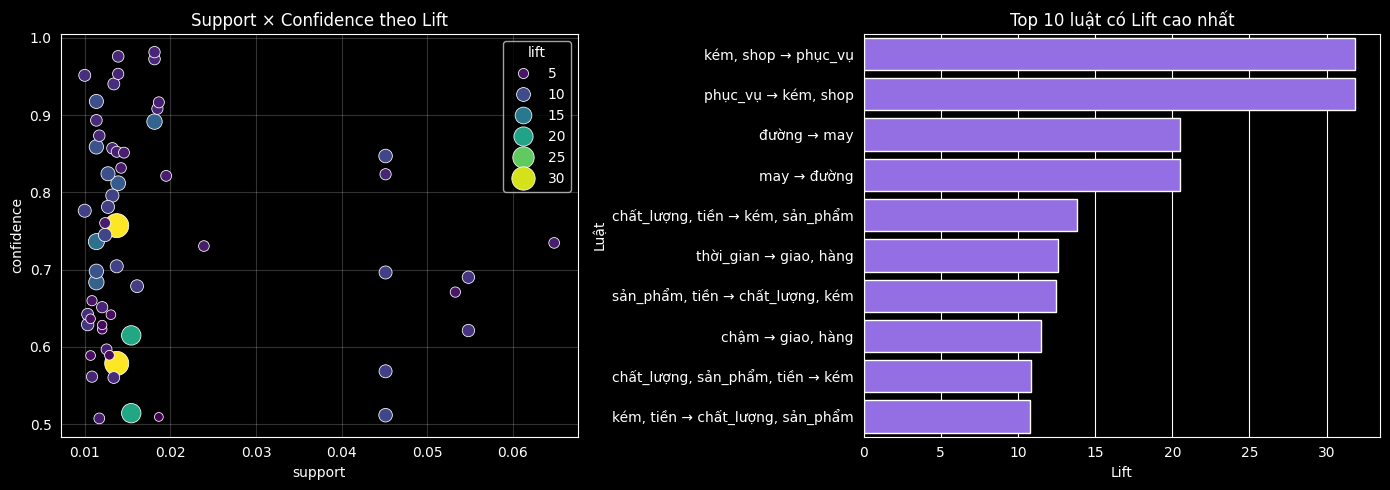

✅ Đã lưu biểu đồ: datas/processed/association_rules_test_summary.png


In [19]:
# Tổng hợp và trực quan hóa chất lượng luật kết hợp
rules_path = MODELS_DIR / 'association_rules.csv'
assert rules_path.exists(), f'Không tìm thấy rules: {rules_path}'

rules_check = pd.read_csv(rules_path)
required_rule_cols = {'antecedents_str', 'consequents_str', 'support', 'confidence', 'lift'}
assert required_rule_cols.issubset(rules_check.columns), 'File luật kết hợp thiếu cột bắt buộc'

rules_summary = rules_check[['support', 'confidence', 'lift']].describe().T.round(4)
print(f'✅ Tổng số luật: {len(rules_check)}')
display(rules_summary)
display(rules_check.sort_values('lift', ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=rules_check, x='support', y='confidence', size='lift', hue='lift',
                palette='viridis', sizes=(40, 300), ax=axes[0])
axes[0].set_title('Support × Confidence theo Lift')
axes[0].grid(alpha=0.2)

top_lift = rules_check.sort_values('lift', ascending=False).head(10).copy()
top_lift['rule'] = top_lift['antecedents_str'] + ' → ' + top_lift['consequents_str']
sns.barplot(data=top_lift, x='lift', y='rule', ax=axes[1], color='#8b5cf6')
axes[1].set_title('Top 10 luật có Lift cao nhất')
axes[1].set_xlabel('Lift')
axes[1].set_ylabel('Luật')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'association_rules_test_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu biểu đồ: datas/processed/association_rules_test_summary.png')


,query,rank,product_id,name,category,similarity_score
0,áo thun nam cotton,1,prs_15435,"Áo thun Nam cotton cá xấu , cổ tròn , cộc tay ...",áo thun,0.4578
1,áo thun nam cotton,2,prs_13401,Áo thun nam cotton 100% Trắng oversize mùa hè ...,áo phông nam,0.4223
2,áo thun nam cotton,3,prs_15337,Áo thun nam cotton 100% Xanh đậm bigsize áo mù...,áo thun,0.3880
3,áo thun nam cotton,4,prs_13220,Áo thun nam cotton 100% Xanh đậm bigsize áo mù...,áo phông nam,0.3526
4,áo thun nam cotton,5,prs_13334,Áo thun nam cotton 100% Xanh đậm form rộng mùa...,áo phông nam,0.3499
5,điện thoại pin trâu camera đẹp,1,968,Điện Thoại Pin Khủng Land Rover A8+,Khác,0.3513
6,điện thoại pin trâu camera đẹp,2,1265,Điện thoại Nokia 1280 chính hãng – CHUẦN - PIN...,Khác,0.3278
7,điện thoại pin trâu camera đẹp,3,prs_15502,điện thoại Vivo Y50 (8GB-128GB) -Pin trâu 5000...,điện thoại,0.3197
8,điện thoại pin trâu camera đẹp,4,1694,"Điện thoại Xiaomi Redmi 6 Pro, 2 sim pin trâu",Khác,0.3168
9,điện thoại pin trâu camera đẹp,5,prs_15480,Điện Thoại Thông Minh CHính Hãng Oppo A3s đã q...,điện thoại,0.2957


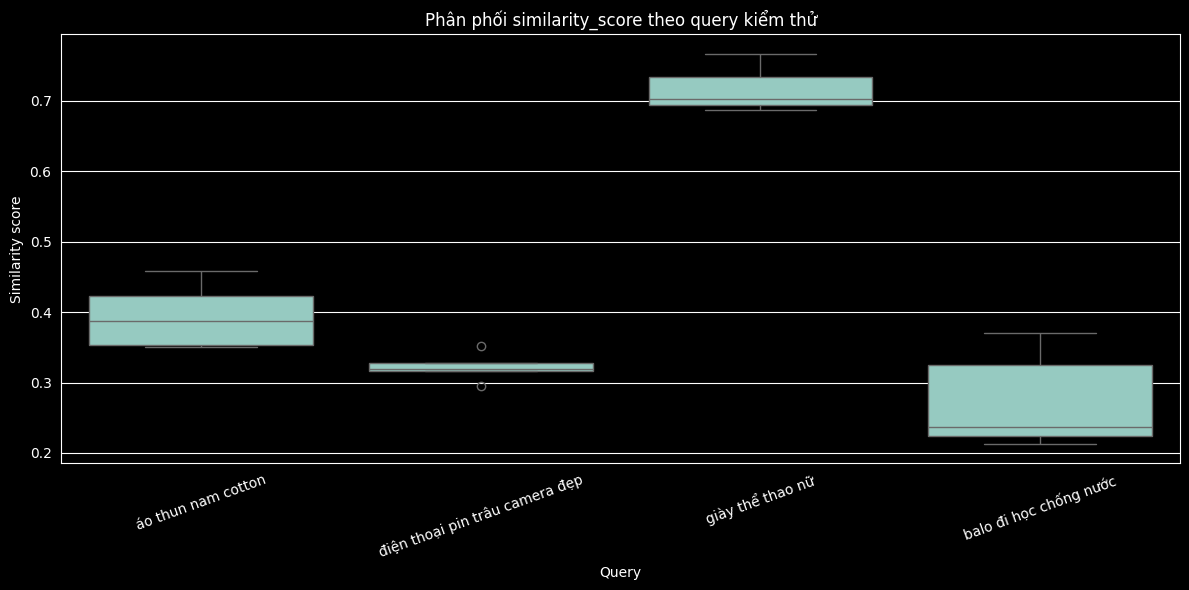

✅ Đã lưu biểu đồ: datas/processed/recommender_query_test_scores.png


In [20]:
# Test nhiều truy vấn cho Content-based Recommender và visualize score
if 'recommender' not in globals():
    recommender = joblib.load(MODELS_DIR / 'recommender.pkl')

query_suite = [
    'áo thun nam cotton',
    'điện thoại pin trâu camera đẹp',
    'giày thể thao nữ',
    'balo đi học chống nước',
]

rec_rows = []
for query in query_suite:
    recs = recommender.recommend_by_query(query, top_k=5)
    for rank, (_, row) in enumerate(recs.iterrows(), start=1):
        rec_rows.append({
            'query': query,
            'rank': rank,
            'product_id': row.get('product_id'),
            'name': row.get('name'),
            'category': row.get('category'),
            'similarity_score': row.get('similarity_score', 0),
        })

rec_eval_df = pd.DataFrame(rec_rows)
assert not rec_eval_df.empty, 'Recommender không trả kết quả cho query suite'
display(rec_eval_df.head(20))

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=rec_eval_df, x='query', y='similarity_score', ax=ax)
ax.set_title('Phân phối similarity_score theo query kiểm thử')
ax.set_xlabel('Query')
ax.set_ylabel('Similarity score')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'recommender_query_test_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu biểu đồ: datas/processed/recommender_query_test_scores.png')


In [21]:
# Smoke test Hybrid Recommender: user cũ, user mới và query cold-start
if 'hybrid_recommend' not in globals():
    print('⚠️ Chưa chạy cell định nghĩa hybrid_recommend ở phía trên; bỏ qua smoke test hybrid.')
else:
    hybrid_cases = [
        {'case': 'old_user_no_query', 'user_id': 'prs_18', 'query': None},
        {'case': 'new_user_with_query', 'user_id': 'new_user_999', 'query': 'tai nghe bluetooth'},
        {'case': 'anonymous_search', 'user_id': 'anonymous', 'query': 'kem dưỡng da'},
    ]

    hybrid_rows = []
    for case in hybrid_cases:
        try:
            recs = hybrid_recommend(user_id=case['user_id'], query=case['query'], top_k=5)
            hybrid_rows.append({
                'case': case['case'],
                'user_id': case['user_id'],
                'query': case['query'] or '',
                'num_results': len(recs),
                'top_product': recs.iloc[0]['name'] if not recs.empty and 'name' in recs.columns else '',
                'top_score': round(float(recs.iloc[0]['final_score']), 4) if not recs.empty and 'final_score' in recs.columns else None,
            })
        except Exception as exc:
            hybrid_rows.append({
                'case': case['case'],
                'user_id': case['user_id'],
                'query': case['query'] or '',
                'num_results': 0,
                'top_product': f'Lỗi: {exc}',
                'top_score': None,
            })

    hybrid_test_df = pd.DataFrame(hybrid_rows)
    display(hybrid_test_df)
    assert hybrid_test_df['num_results'].ge(0).all()
    print('✅ Smoke test hybrid recommender hoàn tất')


🔄 Routing: Kích hoạt Lọc nội dung (CBF) với truy vấn 'sản phẩm nổi bật'...
⭐ Đang áp dụng Sentiment Re-ranking...
🔄 Routing: Kích hoạt Lọc nội dung (CBF) với truy vấn 'tai nghe bluetooth'...
⭐ Đang áp dụng Sentiment Re-ranking...
🔄 Routing: Kích hoạt Lọc nội dung (CBF) với truy vấn 'kem dưỡng da'...
⭐ Đang áp dụng Sentiment Re-ranking...


,case,user_id,query,num_results,top_product,top_score
0,old_user_no_query,prs_18,,5,(Tặng Tất) Giày nam Thời Trang Phong cách 202...,0.4684
1,new_user_with_query,new_user_999,tai nghe bluetooth,5,Tai nghe điện thoại J5,0.4895
2,anonymous_search,anonymous,kem dưỡng da,5,"Trà Dưỡng Sinh Túi Lọc 9 Vị, Bách Thông Dưỡng ...",0.2256


✅ Smoke test hybrid recommender hoàn tất
